In [1]:
import pandas as pd

file_path = "Customer_Churn_Data_Large.xlsx"

demo = pd.read_excel(file_path, sheet_name="Customer_Demographics")
trans = pd.read_excel(file_path, sheet_name="Transaction_History")
service = pd.read_excel(file_path, sheet_name="Customer_Service")
online = pd.read_excel(file_path, sheet_name="Online_Activity")
churn = pd.read_excel(file_path, sheet_name="Churn_Status")

In [2]:
print(demo.head())
print(trans.head())
print(service.head())
print(online.head())
print(churn.head())

   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium
   CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing
   CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1           2           3329      2022-03-17         Inquiry         Resolved
2         

In [3]:
df = demo.merge(trans, on='CustomerID', how='left') \
         .merge(service, on='CustomerID', how='left') \
         .merge(online, on='CustomerID', how='left') \
         .merge(churn, on='CustomerID', how='left')

df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


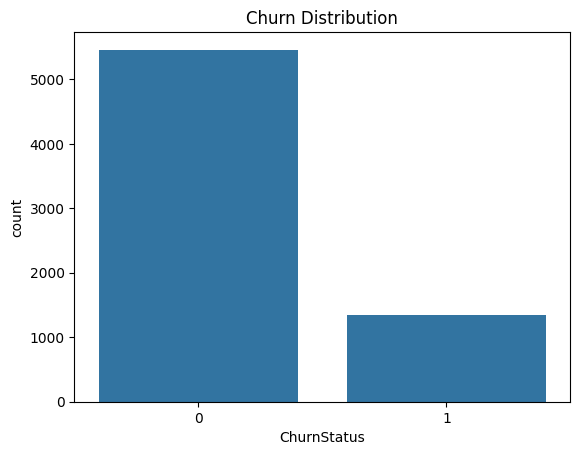

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='ChurnStatus', data=df)
plt.title("Churn Distribution")
plt.show()

In [5]:
df['TotalSpending'] = df.groupby('CustomerID')['AmountSpent'].transform('sum')

In [6]:
df['NumTransactions'] = df.groupby('CustomerID')['TransactionID'].transform('count')

In [7]:
df['NumComplaints'] = df.groupby('CustomerID')['InteractionID'].transform('count')

<Axes: xlabel='ChurnStatus', ylabel='TotalSpending'>

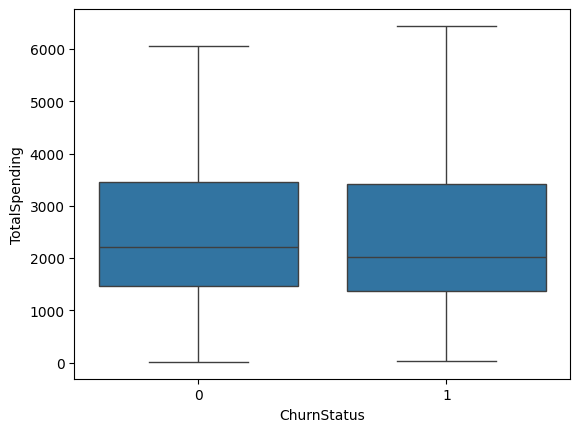

In [8]:
sns.boxplot(x='ChurnStatus', y='TotalSpending', data=df)

<Axes: xlabel='ChurnStatus', ylabel='NumComplaints'>

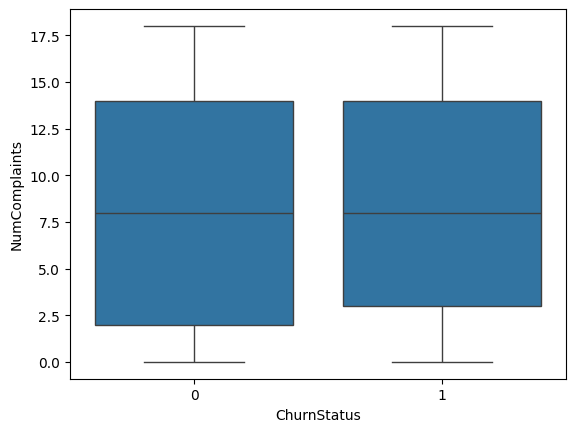

In [9]:
# Complaints vs Churn
sns.boxplot(x='ChurnStatus', y='NumComplaints', data=df)

<Axes: xlabel='ChurnStatus', ylabel='LoginFrequency'>

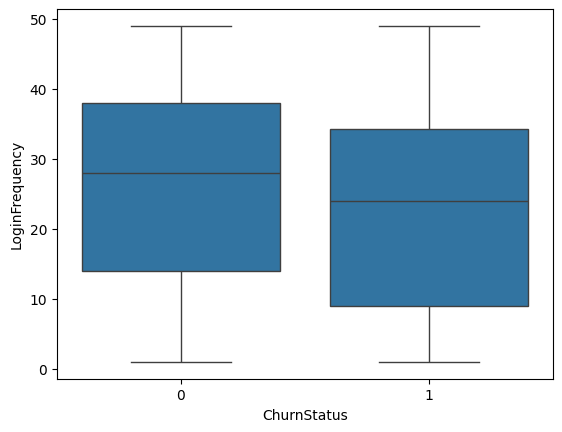

In [10]:
# Activity vs Churn
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=df)

<Axes: xlabel='ChurnStatus', ylabel='NumTransactions'>

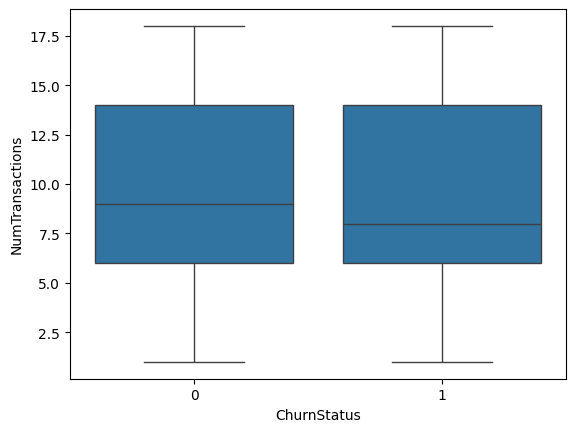

In [11]:
# Transactions vs Churn
sns.boxplot(x='ChurnStatus', y='NumTransactions', data=df)

<Axes: xlabel='LoginFrequency', ylabel='TotalSpending'>

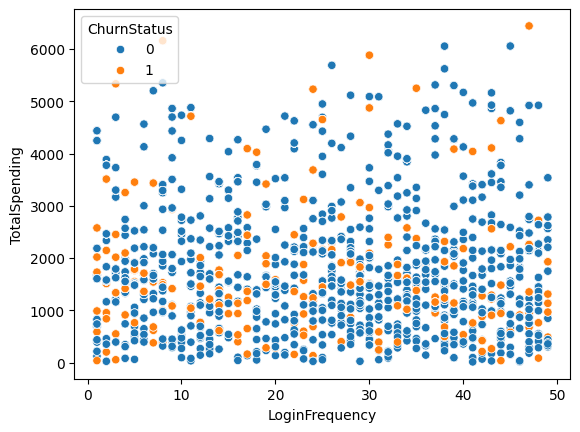

In [12]:
sns.scatterplot(x='LoginFrequency', y='TotalSpending', hue='ChurnStatus', data=df)

In [13]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
InteractionID       1608
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
TotalSpending          0
NumTransactions        0
NumComplaints          0
dtype: int64

In [14]:
df['NumComplaints'] = df['NumComplaints'].fillna(0)

In [15]:
df['HadInteraction'] = df['InteractionID'].notnull().astype(int)

In [16]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
InteractionID       1608
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
TotalSpending          0
NumTransactions        0
NumComplaints          0
HadInteraction         0
dtype: int64

In [17]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [18]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
MaritalStatus          0
IncomeLevel            0
TransactionID          0
TransactionDate        0
AmountSpent            0
ProductCategory        0
InteractionID          0
InteractionDate     1608
InteractionType     1608
ResolutionStatus    1608
LastLoginDate          0
LoginFrequency         0
ServiceUsage           0
ChurnStatus            0
TotalSpending          0
NumTransactions        0
NumComplaints          0
HadInteraction         0
dtype: int64

In [19]:
df = pd.get_dummies(df, columns=['Gender', 'IncomeLevel', 'ServiceUsage'], drop_first=True)

In [20]:
df = pd.get_dummies(df, columns=['MaritalStatus'], drop_first=True)

In [21]:
df.isnull().sum()

CustomerID                        0
Age                               0
TransactionID                     0
TransactionDate                   0
AmountSpent                       0
ProductCategory                   0
InteractionID                     0
InteractionDate                1608
InteractionType                1608
ResolutionStatus               1608
LastLoginDate                     0
LoginFrequency                    0
ChurnStatus                       0
TotalSpending                     0
NumTransactions                   0
NumComplaints                     0
HadInteraction                    0
Gender_M                          0
IncomeLevel_Low                   0
IncomeLevel_Medium                0
ServiceUsage_Online Banking       0
ServiceUsage_Website              0
MaritalStatus_Married             0
MaritalStatus_Single              0
MaritalStatus_Widowed             0
dtype: int64

In [22]:
df.head()

,CustomerID,Age,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,...,NumComplaints,HadInteraction,Gender_M,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Online Banking,ServiceUsage_Website,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,1,62,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,...,1,1,True,True,False,False,False,False,True,False
1,2,65,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,...,7,1,True,True,False,False,True,True,False,False
2,2,65,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,...,7,1,True,True,False,False,True,True,False,False
3,2,65,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,...,7,1,True,True,False,False,True,True,False,False
4,2,65,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,...,7,1,True,True,False,False,True,True,False,False


In [23]:
# 1. Handle missing values
df['NumComplaints'] = df['NumComplaints'].fillna(0)

In [24]:
# 3. Drop unnecessary columns
df = df.drop(['CustomerID', 'TransactionID', 'InteractionID'], axis=1)

In [25]:
df.head()

,Age,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ChurnStatus,...,NumComplaints,HadInteraction,Gender_M,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Online Banking,ServiceUsage_Website,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,62,2022-03-27,416.50,Electronics,2022-03-31,Inquiry,Resolved,2023-10-21,34,0,...,1,1,True,True,False,False,False,False,True,False
1,65,2022-08-08,54.96,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,1,...,7,1,True,True,False,False,True,True,False,False
2,65,2022-07-25,197.50,Electronics,2022-03-17,Inquiry,Resolved,2023-12-05,5,1,...,7,1,True,True,False,False,True,True,False,False
3,65,2022-01-25,101.31,Furniture,2022-03-17,Inquiry,Resolved,2023-12-05,5,1,...,7,1,True,True,False,False,True,True,False,False
4,65,2022-07-24,397.37,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,1,...,7,1,True,True,False,False,True,True,False,False


In [26]:
# Convert to datetime (just to be safe)
df['LastLoginDate'] = pd.to_datetime(df['LastLoginDate'])

In [27]:
# Create new feature
df['DaysSinceLastLogin'] = (pd.to_datetime('today') - df['LastLoginDate']).dt.days

In [28]:
df = df.drop(['TransactionDate', 'InteractionDate', 'LastLoginDate'], axis=1)

In [29]:
print(df.dtypes)

Age                              int64
AmountSpent                    float64
ProductCategory                 object
InteractionType                 object
ResolutionStatus                object
LoginFrequency                   int64
ChurnStatus                      int64
TotalSpending                  float64
NumTransactions                  int64
NumComplaints                    int64
HadInteraction                   int32
Gender_M                          bool
IncomeLevel_Low                   bool
IncomeLevel_Medium                bool
ServiceUsage_Online Banking       bool
ServiceUsage_Website              bool
MaritalStatus_Married             bool
MaritalStatus_Single              bool
MaritalStatus_Widowed             bool
DaysSinceLastLogin               int64
dtype: object


In [30]:
df = pd.get_dummies(df, columns=['ProductCategory', 'InteractionType', 'ResolutionStatus'], drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
X = df.drop('ChurnStatus', axis=1)
y = df['ChurnStatus']

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,        # increase further
    solver='liblinear'    # more stable for small/medium datasets
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


In [61]:
y_pred = model.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8151137197358768


In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1111
           1       0.00      0.00      0.00       252

    accuracy                           0.82      1363
   macro avg       0.41      0.50      0.45      1363
weighted avg       0.66      0.82      0.73      1363



C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [64]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(scores.mean())

C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

0.8012332431590934


C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train, y_train)

model = grid.best_estimator_

C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

[[1111    0]
 [ 252    0]]
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1111
           1       0.00      0.00      0.00       252

    accuracy                           0.82      1363
   macro avg       0.41      0.50      0.45      1363
weighted avg       0.66      0.82      0.73      1363

ROC-AUC: 0.5


C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [67]:
print(model.n_iter_)

[1000]


In [68]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1111
           1       0.00      0.00      0.00       252

    accuracy                           0.82      1363
   macro avg       0.41      0.50      0.45      1363
weighted avg       0.66      0.82      0.73      1363



C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\anaconda3\envs\pydata\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape